<a href="https://colab.research.google.com/github/OlhaZahrebelna/Intelligent-Support-Ticket-Router-using-NLP/blob/main/notebook/03_BERT_FineTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers torch --quiet

In [2]:
# Standard library
import os
import random

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight

# PyTorch
import torch

# Hugging Face
from datasets import Dataset, DatasetDict
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

from pathlib import Path
import shutil

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


For fine-tuning, I selected `bert-base-uncased` because the dataset is relatively small and the main priority is classification quality rather than training speed. BERT is a strong pretrained transformer model that can capture contextual meaning in support ticket texts better than traditional baseline models.


In [4]:
DATA_PATH = "/content/customer_support_tickets_cleaned.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Run the preprocessing notebook first or upload the cleaned CSV file."
    )

df = pd.read_csv(DATA_PATH)

df.head()

,text,subject,body,queue,priority,type,language
0,"Account Disruption Dear Customer Support Team,...",Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high,Incident,en
1,Query About Smart Home System Integration Feat...,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium,Request,en
2,Inquiry Regarding Invoice Details Dear Custome...,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments,low,Request,en
3,Question About Marketing Agency Software Compa...,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales,medium,Problem,en
4,"Feature Query Dear Customer Support,\n\nI hope...",Feature Query,"Dear Customer Support,\n\nI hope this message ...",Technical Support,high,Request,en


In [5]:
df.shape

(23748, 7)

In [6]:
df[["text", "queue"]].isna().sum()

,0
text,0
queue,0


In [7]:
df["queue"].value_counts()

,count
queue,
Technical Support,6858
Product Support,4430
Customer Service,3570
IT Support,2833
Billing and Payments,2420
Returns and Exchanges,1173
Service Outages and Maintenance,937
Sales and Pre-Sales,724
Human Resources,461


### Class Distribution Conclusion

This distribution is consistent with the EDA findings from the first notebook. After filtering the dataset to English-language tickets and removing **4,513 exact duplicate texts (15.97%)**, the final modeling dataset contains **23,748 unique tickets**. However, removing duplicates did not eliminate the substantial target imbalance: `Technical Support` contains **6,858** examples, while `General Inquiry` contains only **342**, a difference of approximately 20×.

This imbalance influenced all subsequent modeling stages. The classical baseline notebook therefore used stratified splitting and Macro F1 as the principal selection metric, and the BERT experiment additionally uses class-weighted loss. Accuracy alone would be misleading because a model could achieve a relatively high score by favoring the dominant support queues while performing poorly on minority classes.

In [8]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["queue"])

In [9]:
pd.DataFrame({
    "Class": label_encoder.classes_,
    "Label": range(len(label_encoder.classes_))
})

,Class,Label
0,Billing and Payments,0
1,Customer Service,1
2,General Inquiry,2
3,Human Resources,3
4,IT Support,4
5,Product Support,5
6,Returns and Exchanges,6
7,Sales and Pre-Sales,7
8,Service Outages and Maintenance,8
9,Technical Support,9


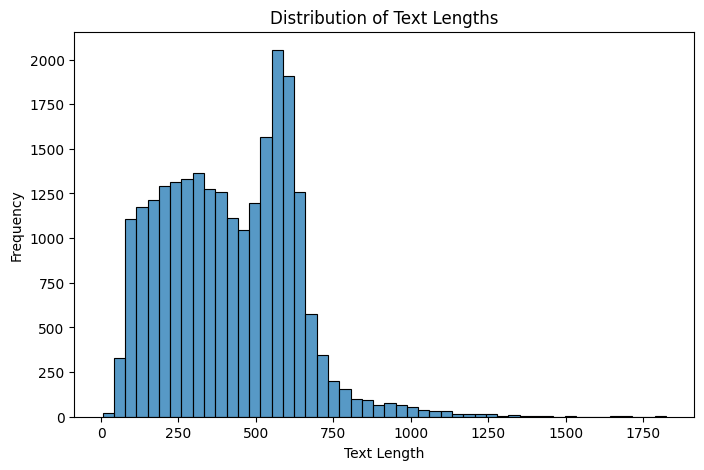

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['text'].apply(len), bins=50)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

In [11]:
X = df["text"]
y = df["label"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train
)

In [14]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [15]:
token_lengths = df["text"].astype(str).apply(
    lambda x: len(tokenizer.tokenize(x)) + 2
)

token_lengths.describe()

,text
count,23748.000000
mean,76.399360
std,40.030802
min,3.000000
25%,45.000000
50%,75.000000
75%,104.000000
max,419.000000


In [16]:
(token_lengths > 128).mean() * 100

np.float64(6.720565942395148)

In [17]:
max_length = 128

### Sequence Length Conclusion

The token-length analysis complements the text-length observations from the EDA notebook. The exploratory analysis showed that ticket bodies contain approximately **55 words on average**, while the BERT tokenizer produces a mean sequence length of about **76 tokens** and a median of **75 tokens**. In total, 75% of tickets contain no more than **104 tokens**, and only about **6.7%** exceed 128 tokens.

Therefore, `max_length = 128` is a reasonable efficiency–coverage compromise. It preserves the complete content of most tickets while reducing GPU memory usage and training time. Because later error analysis shows similar error rates for tickets below and above 128 tokens, truncation is unlikely to be the main factor limiting model quality.

In [18]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding="max_length",
    max_length=max_length
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding="max_length",
    max_length=max_length
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding="max_length",
    max_length=max_length
)

In [19]:
class TicketDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [20]:
train_dataset = TicketDataset(train_encodings, y_train)
val_dataset = TicketDataset(val_encodings, y_val)
test_dataset = TicketDataset(test_encodings, y_test)

In [21]:
train_dataset[0].keys()

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [22]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted
    }

In [23]:
classes = np.arange(len(label_encoder.classes_))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.to_numpy()
)

class_weights = torch.tensor(weights, dtype=torch.float)


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")

        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )

        loss = loss_fn(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [24]:
training_args = TrainingArguments(
    output_dir="./bert_ticket_router",
    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=1e-5,
    warmup_ratio=0.1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.05,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_dir="./logs",
    logging_steps=100,

    save_total_limit=2,
    report_to="none",

    seed=SEED,
    fp16=torch.cuda.is_available()
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [25]:
id2label = {
    i: label
    for i, label in enumerate(label_encoder.classes_)
}

label2id = {
    label: i
    for i, label in enumerate(label_encoder.classes_)
}

In [26]:
model= AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_encoder.classes_),
    id2label=id2label,
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


When loading bert-base-uncased for sequence classification, some pretrained heads related to masked language modeling and next sentence prediction are not used. At the same time, the new classification layer is randomly initialized because the pretrained checkpoint does not contain task-specific weights for the support ticket categories. This is expected and the classification head will be learned during fine-tuning.

In [27]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.002)]
)

In [28]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.857435,1.845752,0.337895,0.309839,0.304610,0.288795,0.342595,0.337895,0.328964
2,1.739800,1.721766,0.384737,0.452246,0.363324,0.365073,0.409582,0.384737,0.385017
3,1.539229,1.600725,0.385789,0.373924,0.426494,0.389576,0.405209,0.385789,0.380988
4,1.386395,1.581211,0.406842,0.433311,0.456302,0.430790,0.438261,0.406842,0.406128
5,1.187169,1.550262,0.434737,0.429017,0.479951,0.448827,0.443943,0.434737,0.432953


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=10690, training_loss=1.5639162804056708, metrics={'train_runtime': 995.3544, 'train_samples_per_second': 85.889, 'train_steps_per_second': 10.74, 'total_flos': 5623744948362240.0, 'train_loss': 1.5639162804056708, 'epoch': 5.0})

In [29]:
train_predictions = trainer.predict(train_dataset)

train_logits = train_predictions.predictions
train_pred_labels = np.argmax(train_logits, axis=-1)

train_true_labels = train_predictions.label_ids

bert_train_f1_macro = f1_score(
    train_true_labels,
    train_pred_labels,
    average="macro"
)

print(f"BERT Train F1 Macro: {bert_train_f1_macro:.4f}")

BERT Train F1 Macro: 0.6454


In [30]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1.187169,1.550262,5,0.434737,0.429017,0.479951,0.448827,0.443943,0.434737,0.432953


{'eval_loss': 1.5502617359161377,
 'eval_accuracy': 0.43473684210526314,
 'eval_macro_precision': 0.42901683001334,
 'eval_macro_recall': 0.4799508966583558,
 'eval_macro_f1': 0.4488273022653565,
 'eval_weighted_precision': 0.4439432846256511,
 'eval_weighted_recall': 0.43473684210526314,
 'eval_weighted_f1': 0.43295311592429003}

### Training and Validation Conclusion

BERT achieves a training Macro F1 of **0.6454** and a validation Macro F1 of **0.4488**, producing a generalization gap of approximately **0.197**. This indicates moderate overfitting, although the gap is smaller than for the tuned Linear SVM, whose cross-validation training and validation Macro F1 scores were **0.8480** and **0.4806**, respectively.

Nevertheless, the BERT validation score remains slightly below the tuned SVM cross-validation score. This means that contextual embeddings did not automatically solve the classification problem. Early stopping limits further overfitting, but the results suggest that the main constraint is not only model capacity. The EDA and baseline experiments already indicated strong class imbalance and semantic overlap among several queue labels, both of which reduce the benefit of using a more complex neural architecture.

In [31]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

print(classification_report(
    y_test.reset_index(drop=True),
    y_pred,
    target_names=label_encoder.classes_
))

print("Macro F1:", f1_score(
    y_test.reset_index(drop=True),
    y_pred,
    average="macro"
))

                                 precision    recall  f1-score   support

           Billing and Payments       0.70      0.79      0.74       484
               Customer Service       0.33      0.32      0.33       714
                General Inquiry       0.18      0.13      0.15        68
                Human Resources       0.48      0.47      0.48        92
                     IT Support       0.31      0.47      0.37       567
                Product Support       0.39      0.36      0.37       886
          Returns and Exchanges       0.36      0.42      0.39       235
            Sales and Pre-Sales       0.35      0.52      0.42       145
Service Outages and Maintenance       0.56      0.60      0.58       187
              Technical Support       0.50      0.37      0.42      1372

                       accuracy                           0.43      4750
                      macro avg       0.42      0.44      0.43      4750
                   weighted avg       0.44      0

### Test-Set Conclusion and Baseline Comparison

On the untouched test set, BERT reaches **43% accuracy** and a **Macro F1 of 0.4250**. Its strongest classes are `Billing and Payments` (F1 = **0.74**) and `Service Outages and Maintenance` (F1 = **0.58**), while `General Inquiry` is the weakest class (F1 = **0.15**).

The tuned Linear SVM from the previous notebook achieved **56% accuracy** and a **Macro F1 of 0.5466** on the same-sized test split. BERT therefore underperforms the strongest classical baseline by approximately **0.122 Macro F1 points** and **13 percentage points of accuracy**. The SVM also achieved higher F1 scores for every reported class except none; the largest BERT weaknesses remain in broad and overlapping categories such as `Customer Service`, `Product Support`, `IT Support`, and `Technical Support`.

This comparison shows that TF-IDF features are highly competitive for this dataset. Many queues contain distinctive lexical signals, such as billing, payment, outage, maintenance, return, or exchange terminology, which a linear model can exploit effectively. BERT's contextual representation does not compensate for ambiguous taxonomy, limited minority-class data, and potentially inconsistent label boundaries.

## Error Analysis

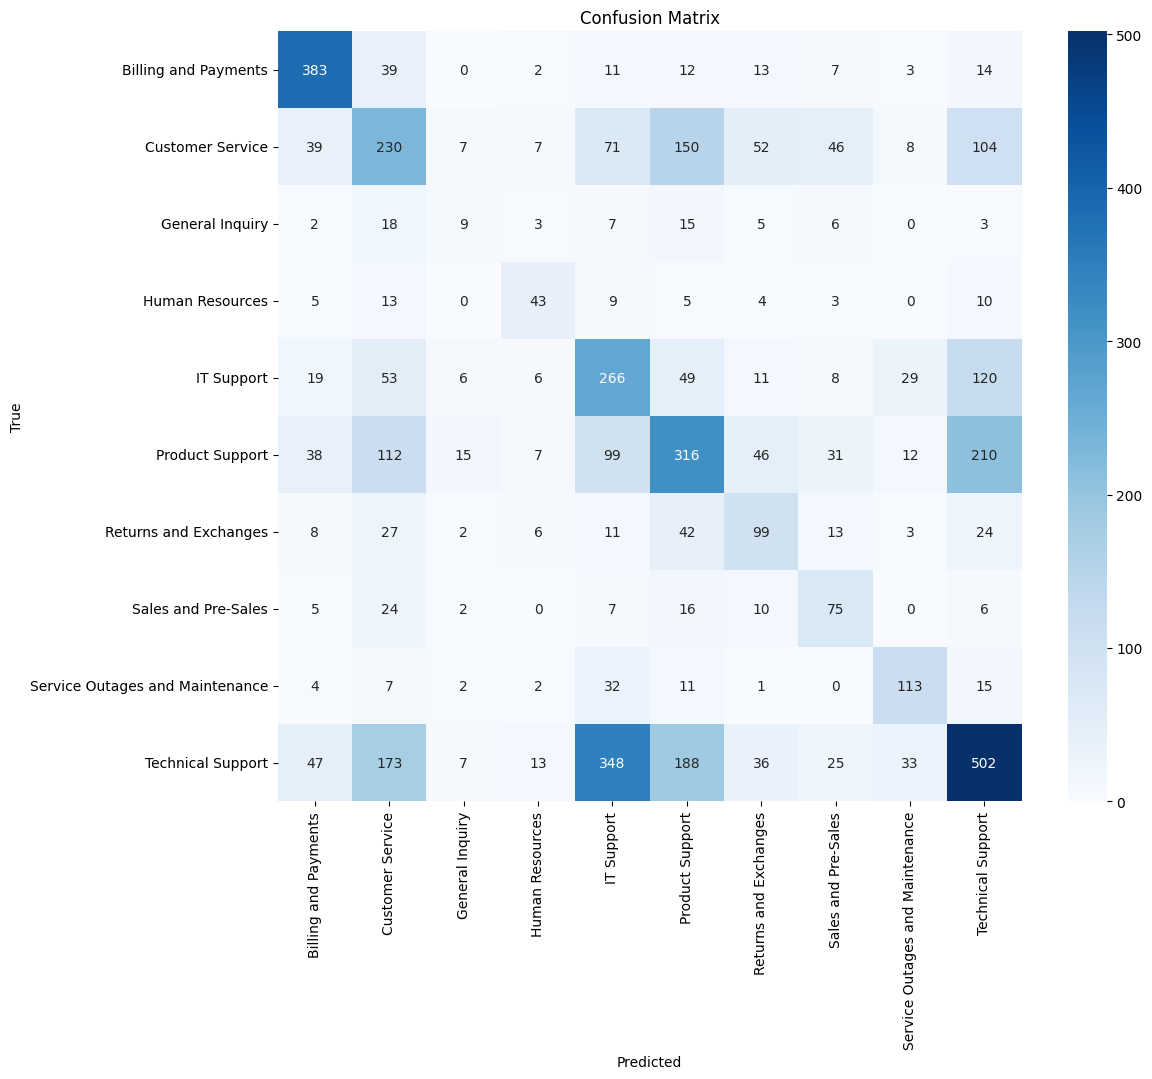

In [32]:
cm = confusion_matrix(y_test.reset_index(drop=True), y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [33]:
y_true = y_test.reset_index(drop=True).to_numpy()
logits = predictions.predictions

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

pred_confidence = probs.max(axis=1)

true_class_probability = probs[np.arange(len(y_true)), y_true]

sorted_probs = np.sort(probs, axis=1)
confidence_margin = sorted_probs[:, -1] - sorted_probs[:, -2]

result_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true_label_id": y_true,
    "predicted_label_id": y_pred,
    "true_label": label_encoder.inverse_transform(y_true),
    "predicted_label": label_encoder.inverse_transform(y_pred),
    "is_error": y_true != y_pred,
    "pred_confidence": pred_confidence,
    "true_class_probability": true_class_probability,
    "confidence_margin": confidence_margin
})

result_df.head()

,text,true_label_id,predicted_label_id,true_label,predicted_label,is_error,pred_confidence,true_class_probability,confidence_margin
0,Issue with Login Sudden Cache Problem I have b...,4,4,IT Support,IT Support,False,0.370843,0.370843,0.011410
1,Problem with Sluggish System Performance An un...,1,4,Customer Service,IT Support,True,0.435237,0.011781,0.181365
2,Query on Payment Options for Medical Data Serv...,0,0,Billing and Payments,Billing and Payments,False,0.992794,0.992794,0.990382
3,Problem with Healthcare Data Encryption Incide...,9,9,Technical Support,Technical Support,False,0.376470,0.376470,0.123967
4,Exploring Digital Strategies for Brand Growth ...,9,1,Technical Support,Customer Service,True,0.352559,0.027480,0.108110


In [34]:
total = len(result_df)
errors_count = result_df["is_error"].sum()
correct_count = total - errors_count

print("Total examples:", total)
print("Correct predictions:", correct_count)
print("Errors:", errors_count)
print("Error rate:", errors_count / total)

Total examples: 4750
Correct predictions: 2036
Errors: 2714
Error rate: 0.5713684210526315


In [35]:
per_class_errors = (
    result_df
    .groupby("true_label")
    .agg(
        total=("is_error", "size"),
        errors=("is_error", "sum"),
        avg_confidence=("pred_confidence", "mean")
    )
    .reset_index()
)

per_class_errors["error_rate"] = per_class_errors["errors"] / per_class_errors["total"]

per_class_errors = per_class_errors.sort_values("error_rate", ascending=False)

per_class_errors

,true_label,total,errors,avg_confidence,error_rate
2,General Inquiry,68,59,0.436351,0.867647
1,Customer Service,714,484,0.402823,0.677871
5,Product Support,886,570,0.406824,0.643341
9,Technical Support,1372,870,0.432301,0.634111
6,Returns and Exchanges,235,136,0.499195,0.578723
3,Human Resources,92,49,0.636810,0.532609
4,IT Support,567,301,0.474979,0.530864
7,Sales and Pre-Sales,145,70,0.610402,0.482759
8,Service Outages and Maintenance,187,74,0.720587,0.395722
0,Billing and Payments,484,101,0.806905,0.208678


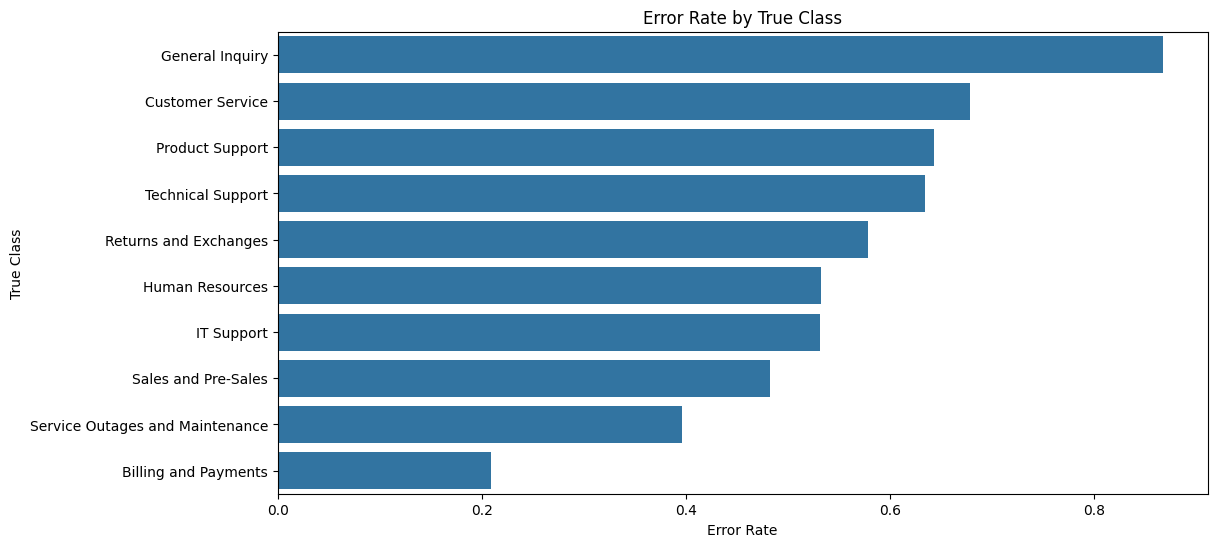

In [36]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=per_class_errors,
    x="error_rate",
    y="true_label"
)

plt.xlabel("Error Rate")
plt.ylabel("True Class")
plt.title("Error Rate by True Class")
plt.show()

In [37]:
errors_df = result_df[result_df["is_error"]].copy()

confusion_pairs = (
    errors_df
    .groupby(["true_label", "predicted_label"])
    .agg(
        count=("text", "size"),
        avg_confidence=("pred_confidence", "mean"),
        avg_true_class_probability=("true_class_probability", "mean")
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

confusion_pairs.head(20)

,true_label,predicted_label,count,avg_confidence,avg_true_class_probability
78,Technical Support,IT Support,348,0.497938,0.257410
49,Product Support,Technical Support,210,0.393474,0.222840
79,Technical Support,Product Support,188,0.381568,0.209652
75,Technical Support,Customer Service,173,0.379173,0.135832
12,Customer Service,Product Support,150,0.375693,0.207084
40,IT Support,Technical Support,120,0.399645,0.220291
42,Product Support,Customer Service,112,0.373873,0.180063
16,Customer Service,Technical Support,104,0.367197,0.151104
45,Product Support,IT Support,99,0.455388,0.098172
11,Customer Service,IT Support,71,0.395142,0.124767


### Error-Analysis Conclusion in the Context of Earlier Findings

The overall BERT test error rate is **57.1%**. The highest class-level error rates occur for `General Inquiry` (**86.8%**), `Customer Service` (**67.8%**), `Product Support` (**64.3%**), and `Technical Support` (**63.4%**). The most frequent confusion is `Technical Support → IT Support` (**348 cases**), followed by `Product Support → Technical Support` (**210 cases**) and `Technical Support → Product Support` (**188 cases**).

These errors confirm the pattern already observed in the Linear SVM analysis. Both model families perform relatively well on categories with distinctive terminology, especially `Billing and Payments`, but struggle to separate the broad support queues. Because the same confusion structure persists across a lexical TF-IDF model and a contextual transformer, the problem is unlikely to be caused solely by feature representation.

The findings instead point to structural limitations in the dataset: severe class imbalance identified during EDA, insufficient examples for minority queues, semantic overlap between labels, and possibly inconsistent annotation. As a result, taxonomy refinement, label auditing, and improved training data are likely to provide greater gains than additional hyperparameter tuning alone.

In [38]:
def show_errors(true_class=None, predicted_class=None, n=10):
    subset = errors_df.copy()

    if true_class is not None:
        subset = subset[subset["true_label"] == true_class]

    if predicted_class is not None:
        subset = subset[subset["predicted_label"] == predicted_class]

    subset = subset.sort_values("pred_confidence", ascending=False)

    return subset[[
        "text",
        "true_label",
        "predicted_label",
        "pred_confidence",
        "true_class_probability",
        "confidence_margin"
    ]].head(n)

In [39]:
show_errors(
    true_class="Customer Service",
    predicted_class="Product Support",
    n=10
)

,text,true_label,predicted_label,pred_confidence,true_class_probability,confidence_margin
104,Assistance Needed for Sluggish Dashboard Acces...,Customer Service,Product Support,0.553559,0.163632,0.386700
2693,Trouble with Campaign Efficiency We are encoun...,Customer Service,Product Support,0.543498,0.214925,0.328572
699,Strategies for Brand Growth Have Hit a Standst...,Customer Service,Product Support,0.543144,0.131040,0.403381
1275,Digital Marketing Strategies Not Meeting Expec...,Customer Service,Product Support,0.517071,0.185089,0.331982
4510,Marketing Campaigns Successful The digital cam...,Customer Service,Product Support,0.513610,0.168545,0.328137
732,Irregular Investment Performance Indicators Am...,Customer Service,Product Support,0.506669,0.192310,0.314359
1690,Underwhelming Results of Digital Campaigns Due...,Customer Service,Product Support,0.504630,0.234217,0.270413
2985,Problem with Evernote Sync I am encountering d...,Customer Service,Product Support,0.499159,0.187985,0.311174
4263,Digital Marketing Campaigns Show Significant U...,Customer Service,Product Support,0.498327,0.155130,0.343197
2970,Delayed Dashboard Loads Encountering delayed l...,Customer Service,Product Support,0.497973,0.224893,0.273080


In [40]:
show_errors(
    true_class="General Inquiry",
    n=10
)

,text,true_label,predicted_label,pred_confidence,true_class_probability,confidence_margin
1163,Request for Integration of Advanced Data Analy...,General Inquiry,Sales and Pre-Sales,0.897818,0.050355,0.847462
702,Problem with Hospital System Security breach f...,General Inquiry,Human Resources,0.877190,0.007705,0.826923
1771,Inquiry on Security Features of Intel Optane M...,General Inquiry,Sales and Pre-Sales,0.825657,0.020408,0.777902
3504,Inquiry About SaaS Features for Project Tracki...,General Inquiry,Returns and Exchanges,0.767388,0.023619,0.665741
1682,Enhance Ubuntu Product Efficiency Seeking to o...,General Inquiry,Sales and Pre-Sales,0.763423,0.104434,0.658989
2743,"Dear Customer Support, we are encountering is...",General Inquiry,IT Support,0.655060,0.009816,0.432622
4358,"Dear Customer Support, we are encountering is...",General Inquiry,IT Support,0.633863,0.011062,0.399308
1841,Revise User Interface Submitting a request to ...,General Inquiry,IT Support,0.595474,0.020050,0.476372
4492,Boost Digital Marketing Efforts enhance brand ...,General Inquiry,IT Support,0.555648,0.019955,0.404925
4279,Investigation Needed for Inaccurate Investment...,General Inquiry,Product Support,0.540205,0.038771,0.367039


In [41]:
result_df["char_length"] = result_df["text"].astype(str).apply(len)
result_df["token_length"] = result_df["text"].astype(str).apply(
    lambda x: len(tokenizer.tokenize(x))
)

length_analysis = (
    result_df
    .assign(length_group=pd.cut(
        result_df["token_length"],
        bins=[0, 64, 128, 256, 512, 10000],
        labels=["0-64", "65-128", "129-256", "257-512", "512+"]
    ))
    .groupby("length_group", observed=False)
    .agg(
        total=("is_error", "size"),
        errors=("is_error", "sum"),
        avg_confidence=("pred_confidence", "mean")
    )
    .reset_index()
)

length_analysis["error_rate"] = length_analysis["errors"] / length_analysis["total"]

length_analysis

,length_group,total,errors,avg_confidence,error_rate
0,0-64,2089,1214,0.477009,0.581139
1,65-128,2394,1349,0.503664,0.563492
2,129-256,258,149,0.474973,0.577519
3,257-512,9,2,0.563777,0.222222
4,512+,0,0,NaN,NaN


### Final Integrated Conclusion

The three notebooks form a complete experimental pipeline from data understanding to classical and transformer-based modeling.

The EDA stage established that the original English-language subset contained **28,261 records**, including **4,513 duplicate ticket texts (15.97%)**. Removing these duplicates produced a clean dataset of **23,748 unique tickets** and reduced the risk of train–test leakage. The analysis also revealed a strongly imbalanced target distribution and substantial overlap among several support categories.

The classical modeling stage showed that a tuned TF-IDF + Linear SVM pipeline is a strong benchmark for this task. It achieved **56% test accuracy** and **0.5466 Macro F1**, outperforming Logistic Regression and demonstrating that many ticket queues can be identified through discriminative words and short phrases. However, its large train–test gap and confusion among related support classes showed that the dataset remains difficult even for the best classical configuration.

The BERT fine-tuning experiment achieved **43% test accuracy** and **0.4250 Macro F1**, which is lower than the tuned Linear SVM by approximately **0.122 Macro F1 points**. BERT performed well on lexically distinctive classes such as `Billing and Payments` and `Service Outages and Maintenance`, but it did not resolve the ambiguity among `Customer Service`, `Product Support`, `IT Support`, and `Technical Support`. Error rates were also similar across the main sequence-length groups, indicating that `max_length = 128` and text truncation were not the principal causes of poor performance.

Overall, the tuned Linear SVM should be retained as the current best model for this dataset. The BERT experiment remains valuable because it demonstrates that increasing model complexity does not guarantee better results when label quality and class separability are the main bottlenecks. The most promising next steps are to:

1. audit mislabeled and ambiguous tickets;
2. clarify, merge, or hierarchically organize overlapping queue categories;
3. collect more representative examples for minority classes;
4. evaluate domain-adapted transformer models and stronger regularization only after improving the label taxonomy;
5. consider a hybrid routing system that automatically assigns high-confidence tickets and sends uncertain cases for manual review.

The central conclusion is that future performance gains are more likely to come from improving the dataset and target definition than from replacing the classifier with a more complex architecture.

## Export Predictions for Manual Audit

In [42]:
val_predictions = trainer.predict(val_dataset)


def prediction_ids(prediction_output):
    logits = prediction_output.predictions

    if isinstance(logits, tuple):
        logits = logits[0]

    return np.argmax(logits, axis=1)


train_pred_ids = prediction_ids(train_predictions)
val_pred_ids = prediction_ids(val_predictions)

bert_train_predictions = pd.DataFrame({
    "record_id": X_train.index.to_numpy(),
    "text": X_train.astype(str).to_numpy(),
    "true_label": label_encoder.inverse_transform(
        y_train.to_numpy()
    ),
    "bert_pred": label_encoder.inverse_transform(
        train_pred_ids
    ),
    "split": "train_in_sample"
})

bert_val_predictions = pd.DataFrame({
    "record_id": X_val.index.to_numpy(),
    "text": X_val.astype(str).to_numpy(),
    "true_label": label_encoder.inverse_transform(
        y_val.to_numpy()
    ),
    "bert_pred": label_encoder.inverse_transform(
        val_pred_ids
    ),
    "split": "validation"
})


bert_predictions_df = (
    pd.concat(
        [bert_train_predictions, bert_val_predictions],
        ignore_index=True
    )
    .sort_values("record_id")
    .reset_index(drop=True)
)

bert_predictions_df["bert_correct"] = (
    bert_predictions_df["bert_pred"]
    == bert_predictions_df["true_label"]
)

bert_audit_candidates = bert_predictions_df[
    ~bert_predictions_df["bert_correct"]
].copy()

expected_record_ids = set(X_train.index).union(set(X_val.index))

assert len(bert_predictions_df) == len(X_train) + len(X_val)
assert len(bert_predictions_df) == len(df) - len(X_test)
assert bert_predictions_df["record_id"].is_unique
assert set(bert_predictions_df["record_id"]) == expected_record_ids
assert set(bert_predictions_df["record_id"]).isdisjoint(set(X_test.index))

print("All BERT predictions:", len(bert_predictions_df))
print("BERT audit candidates:", len(bert_audit_candidates))

bert_audit_candidates.head(20)


All BERT predictions: 18998
BERT audit candidates: 8099


,record_id,text,true_label,bert_pred,split,bert_correct
0,1,Query About Smart Home System Integration Feat...,Returns and Exchanges,Sales and Pre-Sales,validation,False
3,4,"Feature Query Dear Customer Support,\n\nI hope...",Technical Support,Customer Service,train_in_sample,False
5,7,"VPN Access Issue Customer Support,\n\nWe are e...",Product Support,Technical Support,train_in_sample,False
6,8,Immediate Help Needed: Technical Problem with ...,IT Support,Technical Support,train_in_sample,False
7,9,Inquiry for Detailed Information on Agency Off...,Product Support,Sales and Pre-Sales,train_in_sample,False
8,10,Request for Issue Explanation Dear Customer Su...,Product Support,Technical Support,train_in_sample,False
9,11,Inquiry for In-Depth Details on Financial Inst...,Customer Service,Returns and Exchanges,train_in_sample,False
10,12,Enhancing Multi-Unit Marketing Processes Dear ...,Technical Support,Product Support,train_in_sample,False
13,15,Proposal for Upgrades to Big Data Analytics Sy...,Technical Support,IT Support,train_in_sample,False
14,16,Guidelines for Incorporating Seagate Expansion...,Technical Support,IT Support,train_in_sample,False


In [43]:
EXPORT_DIR = Path("/content/bert_audit_files")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

bert_predictions_df.to_csv(
    EXPORT_DIR / "bert_predictions.csv",
    index=False
)

bert_audit_candidates.to_csv(
    EXPORT_DIR / "bert_audit_candidates.csv",
    index=False
)

archive_path = shutil.make_archive(
    "/content/bert_audit_files",
    "zip",
    root_dir=EXPORT_DIR
)

print("Created files:")
print("- bert_predictions.csv")
print("- bert_audit_candidates.csv")
print("- bert_audit_files.zip")

from google.colab import files
files.download(archive_path)


Created files:
- bert_predictions.csv
- bert_audit_candidates.csv
- bert_audit_files.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Save the Fine-Tuned BERT Model

In [44]:
from pathlib import Path
import json
import shutil

MODEL_DIR = Path("/content/bert_ticket_router_model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(MODEL_DIR))

tokenizer.save_pretrained(str(MODEL_DIR))

label_mapping = {
    "id2label": {
        str(index): label
        for index, label in enumerate(label_encoder.classes_)
    },
    "label2id": {
        label: int(index)
        for index, label in enumerate(label_encoder.classes_)
    },
}

with open(
    MODEL_DIR / "label_mapping.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        label_mapping,
        file,
        ensure_ascii=False,
        indent=2,
    )


trainer.state.save_to_json(
    str(MODEL_DIR / "trainer_state.json")
)


inference_config = {
    "base_model": "bert-base-uncased",
    "max_length": int(max_length),
    "num_labels": int(len(label_encoder.classes_)),
    "seed": int(SEED),
    "text_column": "text",
    "label_column": "label",
}

with open(
    MODEL_DIR / "inference_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        inference_config,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Saved model directory:")
print(MODEL_DIR)

print("\nSaved files:")
for path in sorted(MODEL_DIR.iterdir()):
    print("-", path.name)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model directory:
/content/bert_ticket_router_model

Saved files:
- config.json
- inference_config.json
- label_mapping.json
- model.safetensors
- tokenizer.json
- tokenizer_config.json
- trainer_state.json
- training_args.bin


In [45]:
MODEL_ARCHIVE = shutil.make_archive(
    "/content/bert_ticket_router_model",
    "zip",
    root_dir=MODEL_DIR,
)

print("Created model archive:")
print(MODEL_ARCHIVE)


from google.colab import files

files.download(MODEL_ARCHIVE)

Created model archive:
/content/bert_ticket_router_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

reloaded_tokenizer = AutoTokenizer.from_pretrained(
    str(MODEL_DIR)
)

reloaded_model = AutoModelForSequenceClassification.from_pretrained(
    str(MODEL_DIR)
)

assert reloaded_model.config.num_labels == len(label_encoder.classes_)

print("Model and tokenizer were reloaded successfully.")
print("Number of labels:", reloaded_model.config.num_labels)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model and tokenizer were reloaded successfully.
Number of labels: 10
